# Cascade R-CNN AGAR results notebook

This notebook is set up as a safe results notebook for the Cascade R-CNN part of the STRAIN-AI project.

It includes:

1. Safety switches for preprocessing, training, tuning, evaluation, and plotting.
2. GPU and environment checks.
3. Optional tiling, cleaning, countable filtering, and 5-class conversion.
4. Hyperparameter tuning config generation for MMDetection.
5. Result collection from MMDetection JSON logs.
6. YOLO/ViT-style result tables and graphs for Cascade R-CNN.

Default behavior is safe. Preprocessing, training, and tuning are turned off unless you enable them.


## 1. Safety switches

Run this cell first. Keep destructive or long-running steps disabled unless you need them.


In [22]:
# =========================
# Safety switches
# =========================
RUN_TILING = False
RUN_CLEANING = False
RUN_COUNTABLE_FILTER = False
RUN_5CLASS_CONVERSION = False

RUN_DATASET_GRAPHS = True
RUN_WRITE_CONFIGS = True
RUN_TRAINING = True
RUN_HYPERPARAM_TUNING = True
RUN_EVALUATION = True
RUN_CONFUSION_MATRIX_COMMAND = True
RUN_RESULT_GRAPHS = True

# Set this to True only if you are okay with files being overwritten.
ALLOW_OVERWRITE = False

# Project paths
from pathlib import Path
PROJECT_ROOT = Path("/home/jaden/mmdetection")
DATA_ROOT = PROJECT_ROOT / "agar/tiles"
CONFIG_DIR = PROJECT_ROOT / "configs/agar"
WORK_DIR = PROJECT_ROOT / "work_dirs"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CONFIG_DIR:", CONFIG_DIR)
print("WORK_DIR:", WORK_DIR)


PROJECT_ROOT: /home/jaden/mmdetection
DATA_ROOT: /home/jaden/mmdetection/agar/tiles
CONFIG_DIR: /home/jaden/mmdetection/configs/agar
WORK_DIR: /home/jaden/mmdetection/work_dirs


## 2. Imports and environment check


In [23]:
import os
import re
import json
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False
    print("seaborn is not installed. Heatmaps will use matplotlib only.")

try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False
    print("cv2 is not installed. Tiling/cleaning cells need opencv-python.")

print("Current working directory:", os.getcwd())
print("Python executable:")
import sys
print(sys.executable)


Current working directory: /home/jaden/mmdetection/configs/agar
Python executable:
/home/jaden/miniconda3/envs/mmdet311/bin/python


## 3. GPU test

This checks PyTorch first because MMDetection uses PyTorch. TensorFlow is optional.


In [24]:
# PyTorch GPU test
try:
    import torch
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))
        print("CUDA version:", torch.version.cuda)
        x = torch.randn(2048, 2048, device="cuda")
        y = torch.matmul(x, x)
        print("GPU matrix multiplication OK. Output shape:", tuple(y.shape))
except Exception as e:
    print("PyTorch GPU test failed:", e)


PyTorch version: 2.1.0+cu121
CUDA available: True
GPU name: NVIDIA GeForce RTX 2070 SUPER
CUDA version: 12.1
GPU matrix multiplication OK. Output shape: (2048, 2048)


## 4. Path verification

This checks whether the expected project files exist before any processing is run.


In [25]:
paths_to_check = {
    "project root": PROJECT_ROOT,
    "agar original COCO": PROJECT_ROOT / "agar/agar_dataset_coco",
    "tiles root": DATA_ROOT,
    "config dir": CONFIG_DIR,
    "work dir": WORK_DIR,
}

for name, path in paths_to_check.items():
    print(f"{name:20s}: {path} ->", "exists" if path.exists() else "missing")


project root        : /home/jaden/mmdetection -> exists
agar original COCO  : /home/jaden/mmdetection/agar/agar_dataset_coco -> exists
tiles root          : /home/jaden/mmdetection/agar/tiles -> exists
config dir          : /home/jaden/mmdetection/configs/agar -> exists
work dir            : /home/jaden/mmdetection/work_dirs -> exists


## 5. Optional tiling functions

This section defines tiling. It only runs when `RUN_TILING = True`.


In [26]:
TILE_SIZE = 1024
OVERLAP = 0.10
STRIDE = int(TILE_SIZE * (1 - OVERLAP))

USE_NOTIFICATIONS = False
PUSHOVER_TOKEN = ""
PUSHOVER_USER = ""


def notify(message):
    if not USE_NOTIFICATIONS:
        print(message)
        return
    import requests
    requests.post(
        "https://api.pushover.net/1/messages.json",
        data={"token": PUSHOVER_TOKEN, "user": PUSHOVER_USER, "message": message},
        timeout=10,
    )


def safe_write_guard(path):
    path = Path(path)
    if path.exists() and not ALLOW_OVERWRITE:
        raise FileExistsError(
            f"Refusing to overwrite existing path: {path}\n"
            "Set ALLOW_OVERWRITE = True only if you intentionally want to replace it."
        )


def tile_image(img, anns, image_id_start, ann_id_start, out_img_dir):
    h, w = img.shape[:2]
    images = []
    annotations = []
    img_id = image_id_start
    ann_id = ann_id_start

    for y in range(0, h, STRIDE):
        for x in range(0, w, STRIDE):
            x_end = min(x + TILE_SIZE, w)
            y_end = min(y + TILE_SIZE, h)
            tile = img[y:y_end, x:x_end]

            if tile.shape[0] < TILE_SIZE or tile.shape[1] < TILE_SIZE:
                continue

            tile_annotations = []
            for ann in anns:
                bx, by, bw, bh = ann["bbox"]

                if bx + bw < x or by + bh < y or bx > x_end or by > y_end:
                    continue

                new_x = max(bx - x, 0)
                new_y = max(by - y, 0)
                new_w = min(bx + bw, x_end) - max(bx, x)
                new_h = min(by + bh, y_end) - max(by, y)

                if new_w <= 1 or new_h <= 1:
                    continue

                tile_annotations.append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": ann["category_id"],
                    "bbox": [new_x, new_y, new_w, new_h],
                    "area": new_w * new_h,
                    "iscrowd": 0,
                })
                ann_id += 1

            if len(tile_annotations) == 0:
                continue

            file_name = f"{img_id}_{x}_{y}.jpg"
            cv2.imwrite(str(Path(out_img_dir) / file_name), tile)

            images.append({"id": img_id, "file_name": file_name, "height": TILE_SIZE, "width": TILE_SIZE})
            annotations.extend(tile_annotations)
            img_id += 1

    return images, annotations, img_id, ann_id


def process_coco(input_json, img_dir, out_json, out_img_dir):
    if not HAS_CV2:
        raise ImportError("opencv-python is required for tiling.")

    safe_write_guard(out_json)
    out_img_dir = Path(out_img_dir)
    if out_img_dir.exists() and any(out_img_dir.iterdir()) and not ALLOW_OVERWRITE:
        raise FileExistsError(f"Refusing to write into non-empty folder: {out_img_dir}")

    out_img_dir.mkdir(parents=True, exist_ok=True)

    with open(input_json, "r") as f:
        coco = json.load(f)

    annotations_by_image = {}
    for ann in coco["annotations"]:
        annotations_by_image.setdefault(ann["image_id"], []).append(ann)

    all_images = []
    all_annotations = []
    img_id = 1
    ann_id = 1

    for img_info in coco["images"]:
        img_path = Path(img_dir) / img_info["file_name"]
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Skipping unreadable image: {img_path}")
            continue

        anns = annotations_by_image.get(img_info["id"], [])
        imgs, anns_out, img_id, ann_id = tile_image(img, anns, img_id, ann_id, out_img_dir)
        all_images.extend(imgs)
        all_annotations.extend(anns_out)

    out = {"images": all_images, "annotations": all_annotations, "categories": coco["categories"]}

    with open(out_json, "w") as f:
        json.dump(out, f)

    print(f"Saved tiled annotations: {out_json}")
    print(f"Saved tiled images to: {out_img_dir}")
    print(f"Images: {len(all_images)}")
    print(f"Annotations: {len(all_annotations)}")


### Run tiling

This is off by default. Enable only when you want to regenerate tiles.


In [27]:
if RUN_TILING:
    process_coco(
        input_json=PROJECT_ROOT / "agar/agar_dataset_coco/train/annotations/instances_train.json",
        img_dir=PROJECT_ROOT / "agar/agar_dataset_coco/train/images",
        out_json=DATA_ROOT / "instances_train.json",
        out_img_dir=DATA_ROOT / "train/images",
    )
    process_coco(
        input_json=PROJECT_ROOT / "agar/agar_dataset_coco/val/annotations/instances_val.json",
        img_dir=PROJECT_ROOT / "agar/agar_dataset_coco/val/images",
        out_json=DATA_ROOT / "instances_val.json",
        out_img_dir=DATA_ROOT / "val/images",
    )
    notify("Tiling finished")
else:
    print("Skipping tiling because RUN_TILING = False")


Skipping tiling because RUN_TILING = False


## 6. Optional annotation cleaning

This removes invalid bounding boxes, tiny boxes, missing files, and unreadable images. It only runs when `RUN_CLEANING = True`.


In [28]:
MIN_BOX_SIZE = 3

CLEANING_SETS = {
    "train": {"json_in": "instances_train.json", "json_out": "instances_train_clean.json", "img_dir": "train/images"},
    "val": {"json_in": "instances_val.json", "json_out": "instances_val_clean.json", "img_dir": "val/images"},
}


def clean_coco_split(split, cfg):
    json_path = DATA_ROOT / cfg["json_in"]
    out_path = DATA_ROOT / cfg["json_out"]
    img_dir = DATA_ROOT / cfg["img_dir"]
    safe_write_guard(out_path)

    with open(json_path, "r") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]
    images_by_id = {img["id"]: img for img in images}

    valid_annotations = []
    removed_no_bbox = removed_bad_bbox = removed_tiny_bbox = removed_missing_image = 0

    for ann in annotations:
        bbox = ann.get("bbox")
        if bbox is None:
            removed_no_bbox += 1
            continue
        if len(bbox) != 4:
            removed_bad_bbox += 1
            continue
        x, y, w, h = bbox
        if w <= 0 or h <= 0:
            removed_bad_bbox += 1
            continue
        if w < MIN_BOX_SIZE or h < MIN_BOX_SIZE:
            removed_tiny_bbox += 1
            continue
        if ann["image_id"] not in images_by_id:
            removed_missing_image += 1
            continue
        valid_annotations.append(ann)

    valid_image_ids = {ann["image_id"] for ann in valid_annotations}
    valid_images = []
    removed_empty_after_cleaning = removed_unreadable = removed_missing_file = 0

    for img in images:
        if img["id"] not in valid_image_ids:
            removed_empty_after_cleaning += 1
            continue
        img_path = img_dir / img["file_name"]
        if not img_path.exists():
            removed_missing_file += 1
            continue
        if HAS_CV2 and cv2.imread(str(img_path)) is None:
            removed_unreadable += 1
            continue
        valid_images.append(img)

    final_image_ids = {img["id"] for img in valid_images}
    final_annotations = [ann for ann in valid_annotations if ann["image_id"] in final_image_ids]

    cleaned = coco.copy()
    cleaned["images"] = valid_images
    cleaned["annotations"] = final_annotations

    with open(out_path, "w") as f:
        json.dump(cleaned, f)

    summary = {
        "split": split,
        "original_images": len(images),
        "original_annotations": len(annotations),
        "clean_images": len(valid_images),
        "clean_annotations": len(final_annotations),
        "removed_no_bbox": removed_no_bbox,
        "removed_bad_bbox": removed_bad_bbox,
        "removed_tiny_bbox": removed_tiny_bbox,
        "removed_missing_image_refs": removed_missing_image,
        "removed_empty_after_cleaning": removed_empty_after_cleaning,
        "removed_missing_files": removed_missing_file,
        "removed_unreadable_images": removed_unreadable,
        "saved": str(out_path),
    }
    return summary

if RUN_CLEANING:
    summaries = [clean_coco_split(split, cfg) for split, cfg in CLEANING_SETS.items()]
    display(pd.DataFrame(summaries))
else:
    print("Skipping cleaning because RUN_CLEANING = False")


Skipping cleaning because RUN_CLEANING = False


## 7. Optional countable filter

This keeps only images whose original plate ID falls inside known countable ranges. It only runs when `RUN_COUNTABLE_FILTER = True`.


In [29]:
COUNTABLE_RANGES = [(309, 1302), (2712, 8709), (11761, 12617), (12994, 17417)]

COUNTABLE_SETS = {
    "train": {"in": "instances_train_clean.json", "out": "instances_train_countable.json"},
    "val": {"in": "instances_val_clean.json", "out": "instances_val_countable.json"},
}


def is_countable(original_id):
    return any(start <= original_id <= end for start, end in COUNTABLE_RANGES)


def get_original_id(file_name):
    match = re.search(r"\d+", file_name)
    if not match:
        return None
    return int(match.group())


def filter_countable_split(split, cfg):
    in_path = DATA_ROOT / cfg["in"]
    out_path = DATA_ROOT / cfg["out"]
    safe_write_guard(out_path)

    with open(in_path, "r") as f:
        coco = json.load(f)

    kept_images = []
    kept_image_ids = set()
    removed = unknown = 0

    for img in coco["images"]:
        original_id = get_original_id(img["file_name"])
        if original_id is None:
            unknown += 1
            removed += 1
            continue
        if is_countable(original_id):
            kept_images.append(img)
            kept_image_ids.add(img["id"])
        else:
            removed += 1

    kept_annotations = [ann for ann in coco["annotations"] if ann["image_id"] in kept_image_ids]

    out = coco.copy()
    out["images"] = kept_images
    out["annotations"] = kept_annotations

    with open(out_path, "w") as f:
        json.dump(out, f)

    return {
        "split": split,
        "original_images": len(coco["images"]),
        "kept_countable_images": len(kept_images),
        "removed_images": removed,
        "unknown_filename_ids": unknown,
        "original_annotations": len(coco["annotations"]),
        "kept_annotations": len(kept_annotations),
        "saved": str(out_path),
    }

if RUN_COUNTABLE_FILTER:
    summaries = [filter_countable_split(split, cfg) for split, cfg in COUNTABLE_SETS.items()]
    display(pd.DataFrame(summaries))
else:
    print("Skipping countable filtering because RUN_COUNTABLE_FILTER = False")


Skipping countable filtering because RUN_COUNTABLE_FILTER = False


## 8. Optional 5-class conversion

This creates a 5-class COCO dataset for the final Cascade R-CNN experiment. It only runs when `RUN_5CLASS_CONVERSION = True`.


In [30]:
KEEP_CLASSES = ["E.coli", "B.subtilis", "S.aureus", "P.aeruginosa", "C.albicans"]

CLASS_SETS = {
    "train": {"in": "instances_train_countable.json", "out": "instances_train_countable_5class.json"},
    "val": {"in": "instances_val_countable.json", "out": "instances_val_countable_5class.json"},
}


def convert_to_5class_split(split, cfg):
    in_path = DATA_ROOT / cfg["in"]
    out_path = DATA_ROOT / cfg["out"]
    safe_write_guard(out_path)

    with open(in_path, "r") as f:
        coco = json.load(f)

    old_categories = coco["categories"]
    old_id_to_name = {cat["id"]: cat["name"] for cat in old_categories}

    new_categories = []
    old_id_to_new_id = {}

    for new_id, name in enumerate(KEEP_CLASSES):
        matching = [cat for cat in old_categories if cat["name"] == name]
        if not matching:
            raise ValueError(f"Class not found in COCO categories: {name}")
        old_id = matching[0]["id"]
        old_id_to_new_id[old_id] = new_id
        new_categories.append({"id": new_id, "name": name})

    kept_annotations = []
    kept_image_ids = set()

    for ann in coco["annotations"]:
        old_id = ann["category_id"]
        if old_id not in old_id_to_new_id:
            continue
        new_ann = ann.copy()
        new_ann["category_id"] = old_id_to_new_id[old_id]
        kept_annotations.append(new_ann)
        kept_image_ids.add(ann["image_id"])

    kept_images = [img for img in coco["images"] if img["id"] in kept_image_ids]
    out = coco.copy()
    out["images"] = kept_images
    out["annotations"] = kept_annotations
    out["categories"] = new_categories

    with open(out_path, "w") as f:
        json.dump(out, f)

    return {
        "split": split,
        "original_images": len(coco["images"]),
        "kept_images": len(kept_images),
        "original_annotations": len(coco["annotations"]),
        "kept_annotations": len(kept_annotations),
        "saved": str(out_path),
    }

if RUN_5CLASS_CONVERSION:
    summaries = [convert_to_5class_split(split, cfg) for split, cfg in CLASS_SETS.items()]
    display(pd.DataFrame(summaries))
else:
    print("Skipping 5-class conversion because RUN_5CLASS_CONVERSION = False")


Skipping 5-class conversion because RUN_5CLASS_CONVERSION = False


## 9. Dataset graphs

These graphs help document the Cascade R-CNN preprocessing result in the same visual style as the YOLO and ViT report sections.


,split,images,annotations
0,train,12210,72386
1,val,1227,12500


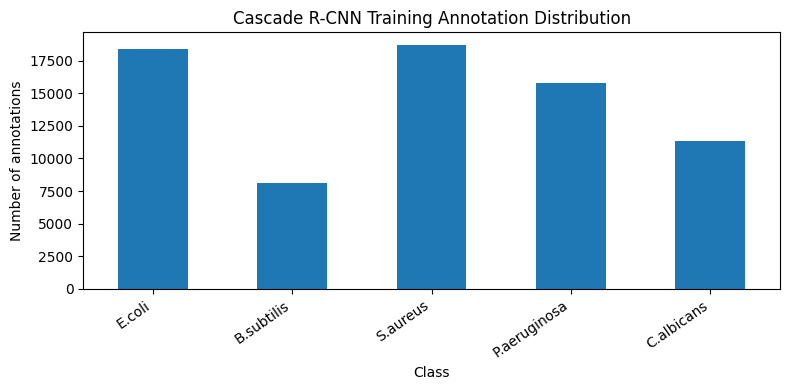

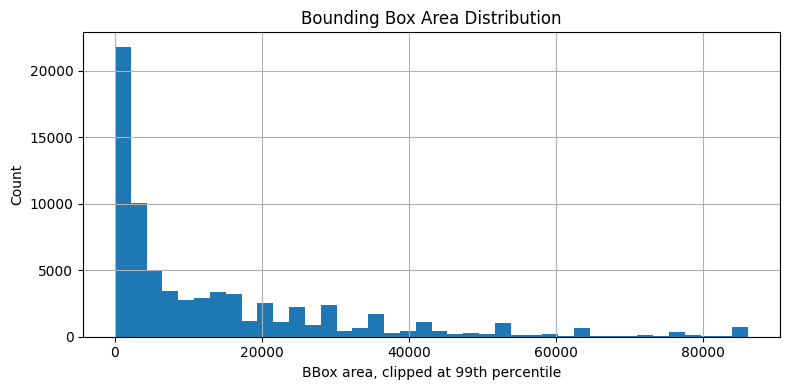

In [31]:
def load_coco(path):
    with open(path, "r") as f:
        return json.load(f)


def coco_class_distribution(coco):
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}
    rows = []
    for ann in coco["annotations"]:
        rows.append({
            "class": cat_id_to_name.get(ann["category_id"], str(ann["category_id"])),
            "area": ann.get("area", ann["bbox"][2] * ann["bbox"][3]),
            "width": ann["bbox"][2],
            "height": ann["bbox"][3],
        })
    return pd.DataFrame(rows)

if RUN_DATASET_GRAPHS:
    train_json = DATA_ROOT / "instances_train_countable_5class.json"
    val_json = DATA_ROOT / "instances_val_countable_5class.json"

    if train_json.exists() and val_json.exists():
        train_coco = load_coco(train_json)
        val_coco = load_coco(val_json)
        train_df = coco_class_distribution(train_coco)
        val_df = coco_class_distribution(val_coco)

        summary = pd.DataFrame([
            {"split": "train", "images": len(train_coco["images"]), "annotations": len(train_coco["annotations"])},
            {"split": "val", "images": len(val_coco["images"]), "annotations": len(val_coco["annotations"])},
        ])
        display(summary)

        class_counts = train_df["class"].value_counts().reindex(KEEP_CLASSES).fillna(0)
        plt.figure(figsize=(8, 4))
        class_counts.plot(kind="bar")
        plt.title("Cascade R-CNN Training Annotation Distribution")
        plt.ylabel("Number of annotations")
        plt.xlabel("Class")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        train_df["area"].clip(upper=train_df["area"].quantile(0.99)).hist(bins=40)
        plt.title("Bounding Box Area Distribution")
        plt.xlabel("BBox area, clipped at 99th percentile")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("5-class COCO files not found. Skipping dataset graphs.")
else:
    print("Skipping dataset graphs because RUN_DATASET_GRAPHS = False")


## 10. Hyperparameter tuning setup

The report states that hardware was a bottleneck for Cascade R-CNN. This tuning section is therefore designed as a small coordinate search, similar to the YOLO approach, not a huge grid search.

The notebook writes separate MMDetection config files. Training only runs when `RUN_HYPERPARAM_TUNING = True`.


In [32]:
# Base config used for tuning.
# Change this if your real final config has a different name.
BASE_CONFIG = CONFIG_DIR / "cascade_rcnn_r50_fpn_agar_tiles.py"
HYPERPARAM_CONFIG_DIR = CONFIG_DIR / "hparam_tuning"
HYPERPARAM_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Small tuning grid to keep runtime realistic.
# Each candidate can be trained for a few epochs first.
TUNING_MAX_EPOCHS = 3
TUNING_VAL_INTERVAL = 1

HYPERPARAM_GRID = [
    {"name": "lr_1e_4_bs1", "lr": 1e-4, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "lr_5e_4_bs1", "lr": 5e-4, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "lr_1e_3_bs1", "lr": 1e-3, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "lr_5e_4_bs2", "lr": 5e-4, "batch_size": 2, "score_thr": 0.05, "nms_iou": 0.50},
    {"name": "lr_5e_4_nms_060", "lr": 5e-4, "batch_size": 1, "score_thr": 0.05, "nms_iou": 0.60},
]


def make_tuning_config(candidate):
    config_path = HYPERPARAM_CONFIG_DIR / f"cascade_rcnn_{candidate['name']}.py"
    work_dir = WORK_DIR / f"cascade_rcnn_hparam_{candidate['name']}"

    text = f"""
_base_ = '../cascade_rcnn_r50_fpn_agar_tiles.py'

work_dir = '{work_dir}'

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs={TUNING_MAX_EPOCHS}, val_interval={TUNING_VAL_INTERVAL})

train_dataloader = dict(batch_size={candidate['batch_size']})
val_dataloader = dict(batch_size=1)
test_dataloader = dict(batch_size=1)

optim_wrapper = dict(
    optimizer=dict(lr={candidate['lr']})
)

model = dict(
    test_cfg=dict(
        rcnn=dict(score_thr={candidate['score_thr']}, nms=dict(type='nms', iou_threshold={candidate['nms_iou']}))
    )
)

default_hooks = dict(
    checkpoint=dict(interval=1, save_best='coco/bbox_mAP', rule='greater')
)
"""
    config_path.write_text(text)
    return config_path, work_dir

if RUN_WRITE_CONFIGS:
    rows = []
    for candidate in HYPERPARAM_GRID:
        config_path, work_dir = make_tuning_config(candidate)
        rows.append({**candidate, "config": str(config_path), "work_dir": str(work_dir)})
    tuning_configs = pd.DataFrame(rows)
    display(tuning_configs)
else:
    print("Skipping config writing because RUN_WRITE_CONFIGS = False")


,name,lr,batch_size,score_thr,nms_iou,config,work_dir
0,lr_1e_4_bs1,0.0001,1,0.05,0.5,/home/jaden/mmdetection/configs/agar/hparam_tu...,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
1,lr_5e_4_bs1,0.0005,1,0.05,0.5,/home/jaden/mmdetection/configs/agar/hparam_tu...,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
2,lr_1e_3_bs1,0.0010,1,0.05,0.5,/home/jaden/mmdetection/configs/agar/hparam_tu...,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
3,lr_5e_4_bs2,0.0005,2,0.05,0.5,/home/jaden/mmdetection/configs/agar/hparam_tu...,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
4,lr_5e_4_nms_060,0.0005,1,0.05,0.6,/home/jaden/mmdetection/configs/agar/hparam_tu...,/home/jaden/mmdetection/work_dirs/cascade_rcnn...


### Run hyperparameter tuning

This will launch multiple training runs. Keep it disabled unless you are ready to train.


In [33]:
def run_command(command, cwd=PROJECT_ROOT):
    print("Running:", " ".join(command))
    process = subprocess.Popen(command, cwd=str(cwd), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in process.stdout:
        print(line, end="")
    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"Command failed with return code {return_code}: {' '.join(command)}")

if RUN_HYPERPARAM_TUNING:
    for candidate in HYPERPARAM_GRID:
        config_path, work_dir = make_tuning_config(candidate)
        run_command(["python", "tools/train.py", str(config_path)])
else:
    print("Skipping hyperparameter tuning because RUN_HYPERPARAM_TUNING = False")
    print("Example command:")
    example_config, _ = make_tuning_config(HYPERPARAM_GRID[0])
    print(f"cd {PROJECT_ROOT}")
    print(f"python tools/train.py {example_config}")


Running: python tools/train.py /home/jaden/mmdetection/configs/agar/hparam_tuning/cascade_rcnn_lr_1e_4_bs1.py
/bin/sh: 1: gcc: not found
05/18 10:24:05 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1720755841
    GPU 0: NVIDIA GeForce RTX 2070 SUPER
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2025.0-Product Build 20241009 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 12.1
  - NVCC architecture flags

## 11. Collect tuning results from MMDetection logs

This cell reads JSON log files from each tuning work directory and extracts COCO metrics.


,name,lr,batch_size,score_thr,nms_iou,status,epoch,bbox_mAP,bbox_mAP_50,bbox_mAP_75,work_dir
0,lr_1e_4_bs1,0.0001,1,0.05,0.5,ok,None,0.367,0.738,0.322,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
1,lr_5e_4_bs1,0.0005,1,0.05,0.5,ok,None,0.412,0.736,0.411,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
2,lr_1e_3_bs1,0.0010,1,0.05,0.5,ok,None,0.444,0.771,0.452,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
3,lr_5e_4_bs2,0.0005,2,0.05,0.5,ok,None,0.440,0.797,0.444,/home/jaden/mmdetection/work_dirs/cascade_rcnn...
4,lr_5e_4_nms_060,0.0005,1,0.05,0.6,ok,None,0.421,0.756,0.418,/home/jaden/mmdetection/work_dirs/cascade_rcnn...


Saved: /home/jaden/mmdetection/work_dirs/cascade_hyperparameter_tuning_results.csv


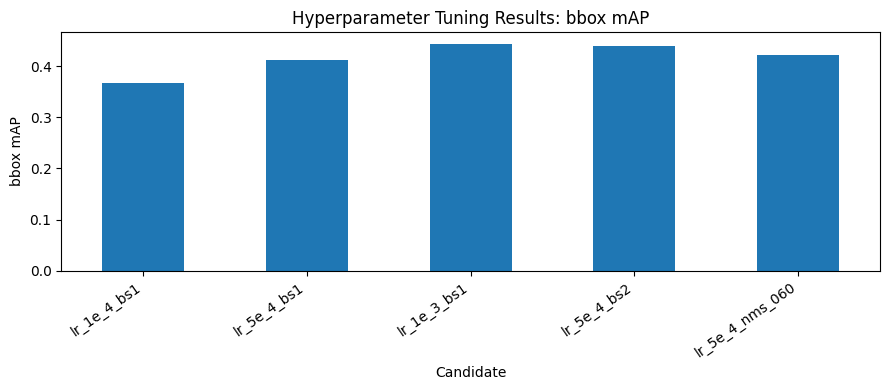

In [34]:
def find_json_logs(work_dir):
    work_dir = Path(work_dir)
    return sorted(work_dir.rglob("*.json"))


def parse_mmdet_json_log(log_path):
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                item = json.loads(line)
            except Exception:
                continue
            if any(k in item for k in ["coco/bbox_mAP", "bbox_mAP", "coco/bbox_mAP_50"]):
                rows.append(item)
    return rows


def collect_tuning_results():
    rows = []
    for candidate in HYPERPARAM_GRID:
        _, work_dir = make_tuning_config(candidate)
        logs = find_json_logs(work_dir)
        metric_rows = []
        for log in logs:
            metric_rows.extend(parse_mmdet_json_log(log))
        if not metric_rows:
            rows.append({**candidate, "status": "no_metrics_found"})
            continue
        last = metric_rows[-1]
        rows.append({
            **candidate,
            "status": "ok",
            "epoch": last.get("epoch"),
            "bbox_mAP": last.get("coco/bbox_mAP", last.get("bbox_mAP")),
            "bbox_mAP_50": last.get("coco/bbox_mAP_50", last.get("bbox_mAP_50")),
            "bbox_mAP_75": last.get("coco/bbox_mAP_75", last.get("bbox_mAP_75")),
            "work_dir": str(work_dir),
        })
    return pd.DataFrame(rows)

if RUN_RESULT_GRAPHS:
    tuning_results = collect_tuning_results()
    display(tuning_results)
    out_csv = WORK_DIR / "cascade_hyperparameter_tuning_results.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    tuning_results.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    ok = tuning_results[tuning_results["status"] == "ok"].copy()
    if len(ok) > 0 and "bbox_mAP" in ok:
        plt.figure(figsize=(9, 4))
        ok.set_index("name")["bbox_mAP"].plot(kind="bar")
        plt.title("Hyperparameter Tuning Results: bbox mAP")
        plt.ylabel("bbox mAP")
        plt.xlabel("Candidate")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No tuning metrics found yet. Run tuning first or place logs in the expected work_dirs.")
else:
    print("Skipping tuning result graphs because RUN_RESULT_GRAPHS = False")


## 12. Final Cascade R-CNN results tables and graphs

These cells make the Cascade section visually consistent with the YOLO and ViT report sections:

- COCO metric bar chart
- per-class precision/recall/F1 table
- per-class metric bar chart
- raw confusion matrix
- normalized confusion matrix

The default numbers below are taken from the current report draft. Replace them if you rerun evaluation.


,metric,value
0,mAP,0.462
1,AP50,0.798
2,AP75,0.478
3,AP small,0.119
4,AP medium,0.323
5,AP large,0.402


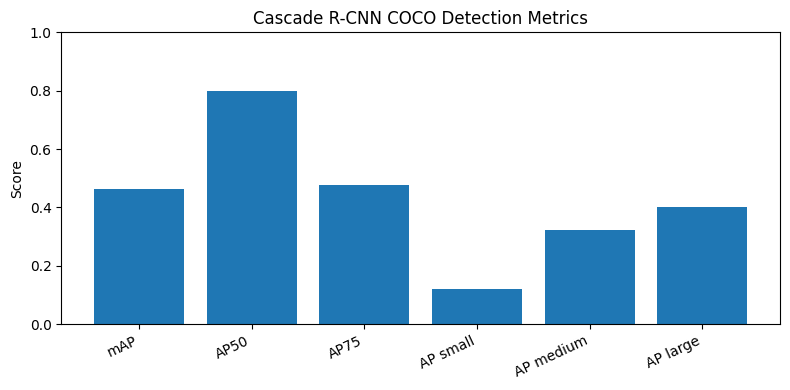

In [35]:
# Final Cascade R-CNN COCO metrics from the current report draft.
cascade_coco_metrics = pd.DataFrame([
    {"metric": "mAP", "value": 0.462},
    {"metric": "AP50", "value": 0.798},
    {"metric": "AP75", "value": 0.478},
    {"metric": "AP small", "value": 0.119},
    {"metric": "AP medium", "value": 0.323},
    {"metric": "AP large", "value": 0.402},
])

display(cascade_coco_metrics)

if RUN_RESULT_GRAPHS:
    plt.figure(figsize=(8, 4))
    plt.bar(cascade_coco_metrics["metric"], cascade_coco_metrics["value"])
    plt.title("Cascade R-CNN COCO Detection Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


,Class,Precision,Recall,F1-score,Support
0,E.coli,0.53,0.81,0.64,3697
1,B.subtilis,0.49,0.77,0.59,1509
2,S.aureus,0.44,0.89,0.58,2756
3,P.aeruginosa,0.53,0.81,0.64,2848
4,C.albicans,0.33,0.71,0.45,1209


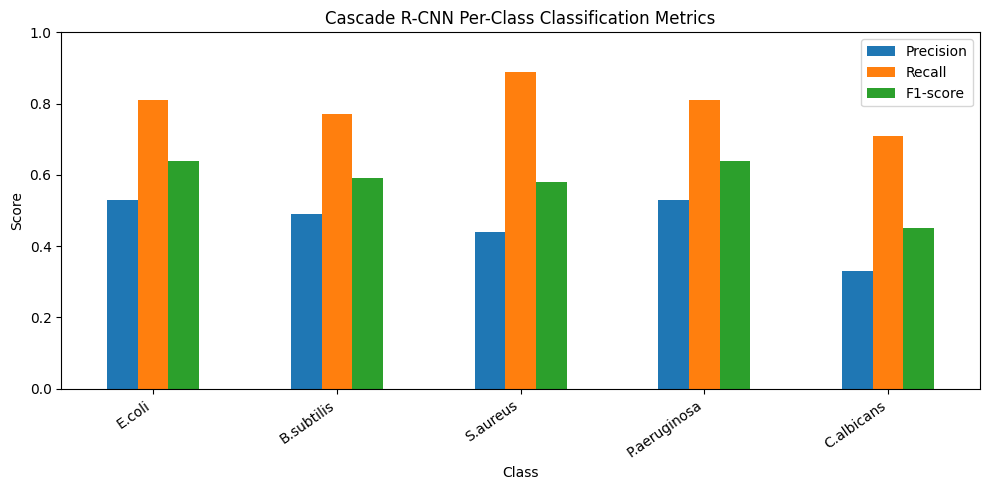

In [36]:
# Final Cascade R-CNN class report from the current report draft.
cascade_class_report = pd.DataFrame([
    {"Class": "E.coli", "Precision": 0.53, "Recall": 0.81, "F1-score": 0.64, "Support": 3697},
    {"Class": "B.subtilis", "Precision": 0.49, "Recall": 0.77, "F1-score": 0.59, "Support": 1509},
    {"Class": "S.aureus", "Precision": 0.44, "Recall": 0.89, "F1-score": 0.58, "Support": 2756},
    {"Class": "P.aeruginosa", "Precision": 0.53, "Recall": 0.81, "F1-score": 0.64, "Support": 2848},
    {"Class": "C.albicans", "Precision": 0.33, "Recall": 0.71, "F1-score": 0.45, "Support": 1209},
])

display(cascade_class_report)

if RUN_RESULT_GRAPHS:
    plot_df = cascade_class_report.set_index("Class")[["Precision", "Recall", "F1-score"]]
    ax = plot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Cascade R-CNN Per-Class Classification Metrics")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


,E.coli,B.subtilis,S.aureus,P.aeruginosa,C.albicans,background
E.coli,2949,2,6,240,0,1483
B.subtilis,28,759,0,25,0,697
S.aureus,0,0,2147,1,49,559
P.aeruginosa,67,8,49,2012,2,710
C.albicans,0,0,16,1,946,246
background,39,11,90,69,142,0


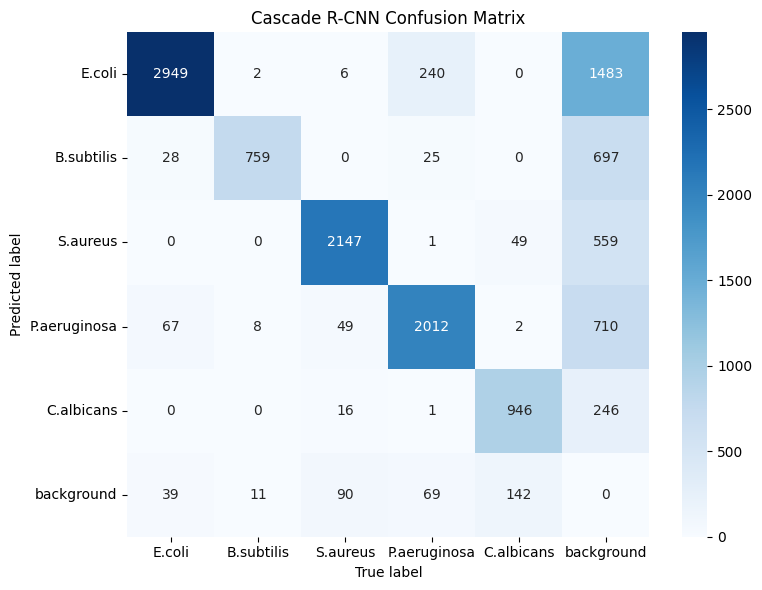

In [37]:
# Raw confusion matrix from the current report draft.
# Rows = predicted label. Columns = true label.
labels = ["E.coli", "B.subtilis", "S.aureus", "P.aeruginosa", "C.albicans", "background"]

cascade_cm = np.array([
    [2949, 2, 6, 240, 0, 1483],
    [28, 759, 0, 25, 0, 697],
    [0, 0, 2147, 1, 49, 559],
    [67, 8, 49, 2012, 2, 710],
    [0, 0, 16, 1, 946, 246],
    [39, 11, 90, 69, 142, 0],
])

cm_df = pd.DataFrame(cascade_cm, index=labels, columns=labels)
display(cm_df)

if RUN_RESULT_GRAPHS:
    plt.figure(figsize=(8, 6))
    if HAS_SEABORN:
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    else:
        plt.imshow(cascade_cm)
        plt.colorbar()
        plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
        plt.yticks(range(len(labels)), labels)
        for i in range(cascade_cm.shape[0]):
            for j in range(cascade_cm.shape[1]):
                plt.text(j, i, str(cascade_cm[i, j]), ha="center", va="center")
    plt.title("Cascade R-CNN Confusion Matrix")
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    plt.tight_layout()
    plt.show()


,E.coli,B.subtilis,S.aureus,P.aeruginosa,C.albicans,background
E.coli,0.957,0.003,0.003,0.102,0.000,0.401
B.subtilis,0.009,0.973,0.000,0.011,0.000,0.189
S.aureus,0.000,0.000,0.930,0.000,0.043,0.151
P.aeruginosa,0.022,0.010,0.021,0.857,0.002,0.192
C.albicans,0.000,0.000,0.007,0.000,0.831,0.067
background,0.013,0.014,0.039,0.029,0.125,0.000


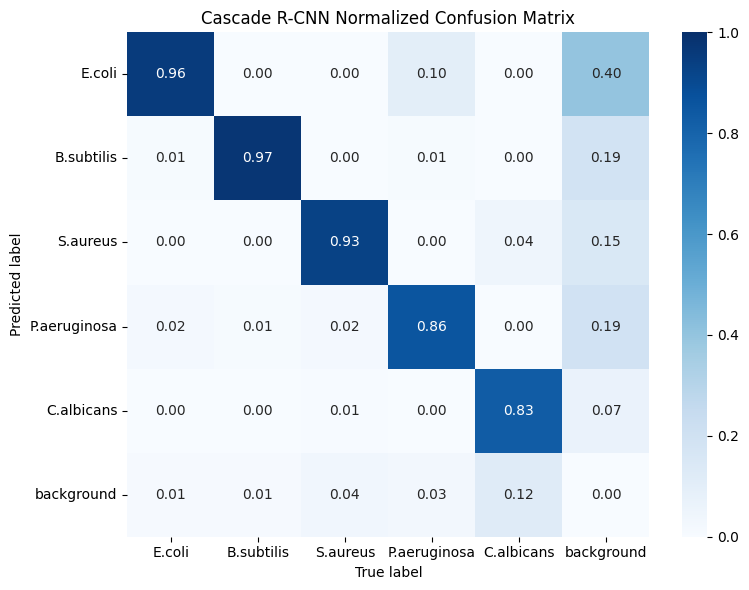

In [38]:
# Normalized confusion matrix, useful for report discussion.
# Normalization is done by true class column so each column shows where true instances went.
cm_col_sum = cascade_cm.sum(axis=0, keepdims=True)
cm_norm = np.divide(cascade_cm, cm_col_sum, out=np.zeros_like(cascade_cm, dtype=float), where=cm_col_sum != 0)
cm_norm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)

display(cm_norm_df.round(3))

if RUN_RESULT_GRAPHS:
    plt.figure(figsize=(8, 6))
    if HAS_SEABORN:
        sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
    else:
        plt.imshow(cm_norm, vmin=0, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
        plt.yticks(range(len(labels)), labels)
        for i in range(cm_norm.shape[0]):
            for j in range(cm_norm.shape[1]):
                plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")
    plt.title("Cascade R-CNN Normalized Confusion Matrix")
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    plt.tight_layout()
    plt.show()


## 13. Run final evaluation commands

Use this section when you want to regenerate `results.pkl` and confusion matrix outputs.


In [39]:
FINAL_CONFIG = CONFIG_DIR / "cascade_rcnn_r50_fpn_agar_tiles.py"
FINAL_CHECKPOINT = WORK_DIR / "cascade_rcnn_r50_fpn_agar_tiles/epoch_20.pth"
RESULTS_PKL = PROJECT_ROOT / "results.pkl"
CONFUSION_OUT_DIR = WORK_DIR / "cascade_rcnn_r50_fpn_agar_tiles/confusion_matrix"

if RUN_EVALUATION:
    run_command([
        "python", "tools/test.py",
        str(FINAL_CONFIG),
        str(FINAL_CHECKPOINT),
        "--out", str(RESULTS_PKL),
    ])
else:
    print("Skipping evaluation because RUN_EVALUATION = False")
    print("Evaluation command:")
    print(f"cd {PROJECT_ROOT}")
    print(f"python tools/test.py {FINAL_CONFIG} {FINAL_CHECKPOINT} --out {RESULTS_PKL}")

if RUN_CONFUSION_MATRIX_COMMAND:
    run_command([
        "python", "tools/analysis_tools/confusion_matrix.py",
        str(FINAL_CONFIG),
        str(RESULTS_PKL),
        str(CONFUSION_OUT_DIR),
    ])
else:
    print("Skipping confusion matrix command because RUN_CONFUSION_MATRIX_COMMAND = False")
    print("Confusion matrix command:")
    print(f"python tools/analysis_tools/confusion_matrix.py {FINAL_CONFIG} {RESULTS_PKL} {CONFUSION_OUT_DIR}")


Running: python tools/test.py /home/jaden/mmdetection/configs/agar/cascade_rcnn_r50_fpn_agar_tiles.py /home/jaden/mmdetection/work_dirs/cascade_rcnn_r50_fpn_agar_tiles/epoch_20.pth --out /home/jaden/mmdetection/results.pkl
/bin/sh: 1: gcc: not found
05/18 19:42:46 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1990091071
    GPU 0: NVIDIA GeForce RTX 2070 SUPER
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2025.0-Product Build 20241009 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provid

## 14. Report-ready interpretation

Use this text below your graphs or adapt it for the report.


In [40]:
interpretation = """
The Cascade R-CNN model was evaluated as a colony-level object detector. The model achieved an overall mAP of 0.462 and an AP50 of 0.798, which shows that the detector was often able to find colonies when a moderate IoU threshold was used. The lower AP75 score of 0.478 shows that precise bounding box alignment was more difficult.

Object size had a clear effect on performance. The AP for small objects was 0.119, while medium and large objects reached 0.323 and 0.402. This confirms that small bacterial colonies remained the hardest cases, even after tiling.

The class report shows that E.coli and P.aeruginosa achieved the strongest F1-scores, while C.albicans was the weakest class. The confusion matrix also shows many background false positives. This means the model sometimes detected colonies in regions where no colony was annotated. Future improvements should focus on confidence threshold tuning, NMS tuning, better annotation cleaning, more negative/background examples, and additional small-object augmentation.
"""
print(interpretation)



The Cascade R-CNN model was evaluated as a colony-level object detector. The model achieved an overall mAP of 0.462 and an AP50 of 0.798, which shows that the detector was often able to find colonies when a moderate IoU threshold was used. The lower AP75 score of 0.478 shows that precise bounding box alignment was more difficult.

Object size had a clear effect on performance. The AP for small objects was 0.119, while medium and large objects reached 0.323 and 0.402. This confirms that small bacterial colonies remained the hardest cases, even after tiling.

The class report shows that E.coli and P.aeruginosa achieved the strongest F1-scores, while C.albicans was the weakest class. The confusion matrix also shows many background false positives. This means the model sometimes detected colonies in regions where no colony was annotated. Future improvements should focus on confidence threshold tuning, NMS tuning, better annotation cleaning, more negative/background examples, and additiona